# Session 4 — Missing Data Handling
**ICU Mortality Prediction · Predictive Modeling in Healthcare**

We compare multiple strategies for dealing with missing data and evaluate their effect on CatBoost model performance.

---
## 0. Imports & Config

In [97]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from scipy.interpolate import UnivariateSpline

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D


from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, \
    precision_recall_curve, brier_score_loss, confusion_matrix
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.utils import resample

from catboost import CatBoostClassifier, Pool

import statsmodels.api as sm

SEED   = 42
TARGET = 'hospital_death'
DATA_PATH = 'training_v2.csv'

CB_PARAMS = dict(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    auto_class_weights="Balanced",
    eval_metric='AUC',
    random_seed=SEED,
    verbose=0,
)

print('Imports OK')

Imports OK


---
## 1. Load Data & Remove Apache Columns

In [98]:
raw = pd.read_csv(DATA_PATH)
print(f'Raw shape: {raw.shape}')

# Drop Apache score columns (they are leak-prone / derived scores)
apache_cols = [c for c in raw.columns if 'apache' in c.lower()]
print(f'Dropping {len(apache_cols)} Apache columns: {apache_cols}')

df = raw.drop(columns=apache_cols)

# Also drop ID columns that carry no predictive signal
id_cols = ['encounter_id', 'patient_id', 'hospital_id', 'icu_id']
df = df.drop(columns=[c for c in id_cols if c in df.columns])

print(f'Working shape: {df.shape}')
print(f'Target distribution:\n{df[TARGET].value_counts()}')

Raw shape: (91713, 186)
Dropping 32 Apache columns: ['albumin_apache', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'bilirubin_apache', 'bun_apache', 'creatinine_apache', 'fio2_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'glucose_apache', 'heart_rate_apache', 'hematocrit_apache', 'intubated_apache', 'map_apache', 'paco2_apache', 'paco2_for_ph_apache', 'pao2_apache', 'ph_apache', 'resprate_apache', 'sodium_apache', 'temp_apache', 'urineoutput_apache', 'ventilated_apache', 'wbc_apache', 'apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob', 'apache_3j_bodysystem', 'apache_2_bodysystem']
Working shape: (91713, 150)
Target distribution:
hospital_death
0    83798
1     7915
Name: count, dtype: int64


---
## 2. EDA — Missing Data Overview

In [99]:
miss = df.isnull().mean().sort_values(ascending=False)
miss_nonzero = miss[miss > 0]

print(f'Columns with missing values: {len(miss_nonzero)} / {len(df.columns)}')
print(f'Rows with ≥1 missing value:  {df.isnull().any(axis=1).sum()} / {len(df)}')
print(f'Complete rows:               {df.dropna().shape[0]} / {len(df)}')
print()

# Summary table
miss_df = pd.DataFrame({
    'Missing N': df.isnull().sum(),
    'Missing %': (df.isnull().mean() * 100).round(1),
    'Dtype': df.dtypes,
}).query('`Missing N` > 0').sort_values('Missing %', ascending=False)
print(miss_df.to_string())

Columns with missing values: 144 / 150
Rows with ≥1 missing value:  91602 / 91713
Complete rows:               111 / 91713

                             Missing N  Missing %    Dtype
h1_bilirubin_min                 84619       92.3  float64
h1_bilirubin_max                 84619       92.3  float64
h1_lactate_max                   84369       92.0  float64
h1_lactate_min                   84369       92.0  float64
h1_albumin_min                   83824       91.4  float64
h1_albumin_max                   83824       91.4  float64
h1_pao2fio2ratio_min             80195       87.4  float64
h1_pao2fio2ratio_max             80195       87.4  float64
h1_arterial_ph_max               76424       83.3  float64
h1_arterial_ph_min               76424       83.3  float64
h1_hco3_min                      76094       83.0  float64
h1_hco3_max                      76094       83.0  float64
h1_arterial_pco2_min             75959       82.8  float64
h1_arterial_pco2_max             75959       82.8 

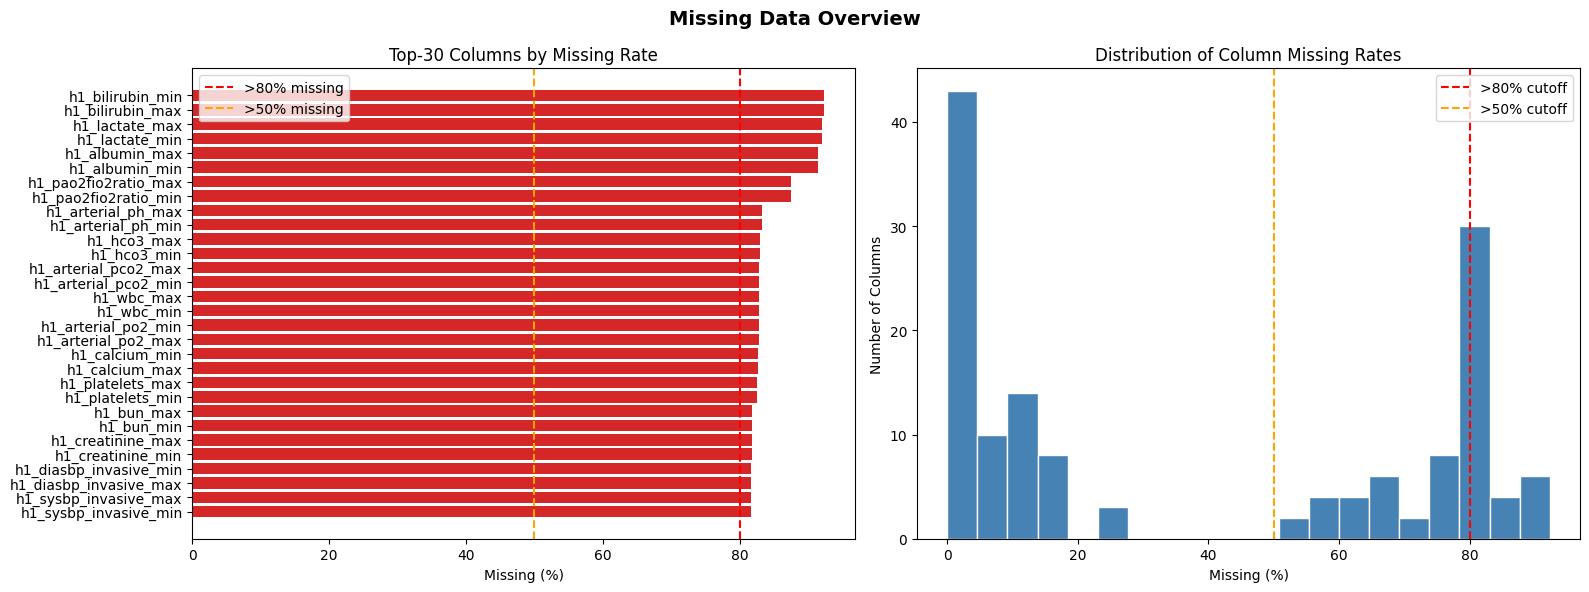


Columns >80% missing: 34
Columns >50% missing: 66


In [100]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: top-30 most-missing columns
top = miss_nonzero.head(30)
colors = ['#d62728' if v > 0.5 else '#1f77b4' for v in top.values]
axes[0].barh(top.index[::-1], top.values[::-1] * 100, color=colors[::-1])
axes[0].axvline(80, color='red', linestyle='--', label='>80% missing')
axes[0].axvline(50, color='orange', linestyle='--', label='>50% missing')
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Top-30 Columns by Missing Rate')
axes[0].legend()

# Histogram: distribution of missing rates across all columns
axes[1].hist(miss_nonzero.values * 100, bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(80, color='red', linestyle='--', label='>80% cutoff')
axes[1].axvline(50, color='orange', linestyle='--', label='>50% cutoff')
axes[1].set_xlabel('Missing (%)')
axes[1].set_ylabel('Number of Columns')
axes[1].set_title('Distribution of Column Missing Rates')
axes[1].legend()

plt.suptitle('Missing Data Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nColumns >80% missing: {(miss_nonzero > 0.8).sum()}")
print(f"Columns >50% missing: {(miss_nonzero > 0.5).sum()}")

---
## 3. Helper Utilities (Shared Across All Experiments)

In [101]:
# ── Identify feature types ──────────────────────────────────────────────────
CAT_COLS = [c for c in df.select_dtypes(include=['object', 'string']).columns if c != TARGET]
BIN_COLS = [c for c in df.columns if c != TARGET and df[c].dropna().isin([0, 1]).all() and c not in CAT_COLS]

print(f'Categorical columns ({len(CAT_COLS)}): {CAT_COLS}')
print(f'Binary columns     ({len(BIN_COLS)}): {BIN_COLS[:10]} ...')

# ── Train / val split (stratified, done once on original df) ────────────────
X_all = df.drop(columns=[TARGET])
y_all = df[TARGET]
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
print(f'Train: {X_train_raw.shape}, Val: {X_val_raw.shape}')


# ── Evaluation function ─────────────────────────────────────────────────────
def evaluate_model(model, X_val_proc, y_val, cat_features=None, threshold=0.5):
    if cat_features is not None:
        pool = Pool(X_val_proc, cat_features=cat_features)
        probs = model.predict_proba(pool)[:, 1]
    else:
        probs = model.predict_proba(X_val_proc)[:, 1]

    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0   # recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv         = tp / (tp + fp) if (tp + fp) > 0 else 0   # precision
    npv         = tn / (tn + fn) if (tn + fn) > 0 else 0

    return {
        'AUROC':       round(roc_auc_score(y_val, probs), 4),
        'AUPRC':       round(average_precision_score(y_val, probs), 4),
        'Brier':       round(brier_score_loss(y_val, probs), 4),
        'Sensitivity': round(sensitivity, 4),
        'Specificity': round(specificity, 4),
        'PPV':         round(ppv, 4),
        'NPV':         round(npv, 4),
        'probs':       probs,
    }


# ── Smooth calibration via LOESS ────────────────────────────────────────────
def plot_spline_calibration(ax, probs, y_true, label, color):
    order = np.argsort(probs)
    x = np.array(probs)[order]
    y = np.array(y_true)[order]
    spline = UnivariateSpline(x, y, k=3, s=len(x) * 0.1)
    x_smooth = np.linspace(x.min(), x.max(), 300)
    ax.plot(x_smooth, np.clip(spline(x_smooth), 0, 1), label=label, color=color, linewidth=2)


# ── Per-experiment plot (ROC, PR, Calibration) ──────────────────────────────
def plot_experiment(name, probs, y_val):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    y_np = np.array(y_val)

    # ROC
    fpr, tpr, _ = roc_curve(y_np, probs)
    auroc = roc_auc_score(y_np, probs)
    axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {auroc:.4f}')
    axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title(f'ROC — {name}'); axes[0].legend()

    # PR
    prec, rec, _ = precision_recall_curve(y_np, probs)
    auprc = average_precision_score(y_np, probs)
    baseline = y_np.mean()
    axes[1].plot(rec, prec, lw=2, label=f'AP = {auprc:.4f}')
    axes[1].axhline(baseline, color='k', linestyle='--', alpha=0.4, label='Baseline')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title(f'PR Curve — {name}'); axes[1].legend()

    # Calibration
    axes[2].plot([0,1],[0,1],'k--', alpha=0.4, label='Perfect')
    plot_spline_calibration(axes[2], probs, y_np, label=name, color='steelblue')
    axes[2].set_xlabel('Mean Predicted Probability')
    axes[2].set_ylabel('Observed Fraction')
    axes[2].set_title(f'Calibration — {name}')
    axes[2].legend()

    plt.tight_layout()
    plt.show()


# ── Results tracker ──────────────────────────────────────────────────────────
RESULTS = []   # list of dicts
ALL_PROBS = {} # name → probs  (for combined plots)

def record(name, metrics):
    RESULTS.append({
        'Strategy':    name,
        'AUROC':       metrics['AUROC'],
        'AUPRC':       metrics['AUPRC'],
        'Brier':       metrics['Brier'],
        'Sensitivity': metrics['Sensitivity'],
        'Specificity': metrics['Specificity'],
        'PPV':         metrics['PPV'],
        'NPV':         metrics['NPV'],
    })
    ALL_PROBS[name] = metrics['probs']
    print(f"{name:45s}  AUROC={metrics['AUROC']:.4f}  AUPRC={metrics['AUPRC']:.4f}  "
          f"Brier={metrics['Brier']:.4f}  Sens={metrics['Sensitivity']:.4f}  "
          f"Spec={metrics['Specificity']:.4f}  PPV={metrics['PPV']:.4f}  NPV={metrics['NPV']:.4f}")

print('Helpers defined.')

Categorical columns (6): ['ethnicity', 'gender', 'hospital_admit_source', 'icu_admit_source', 'icu_stay_type', 'icu_type']
Binary columns     (10): ['elective_surgery', 'readmission_status', 'aids', 'cirrhosis', 'diabetes_mellitus', 'hepatic_failure', 'immunosuppression', 'leukemia', 'lymphoma', 'solid_tumor_with_metastasis'] ...
Train: (73370, 149), Val: (18343, 149)
Helpers defined.


---
## 4. Experiment A — Complete Case Analysis

Training rows after dropping incomplete: 91 / 73370 (0.1%)
Validation rows after dropping incomplete: 20 / 18343
A: Complete Case Analysis                      AUROC=0.8571  AUPRC=0.7878  Brier=0.1825  Sens=0.4286  Spec=0.9231  PPV=0.7500  NPV=0.7500


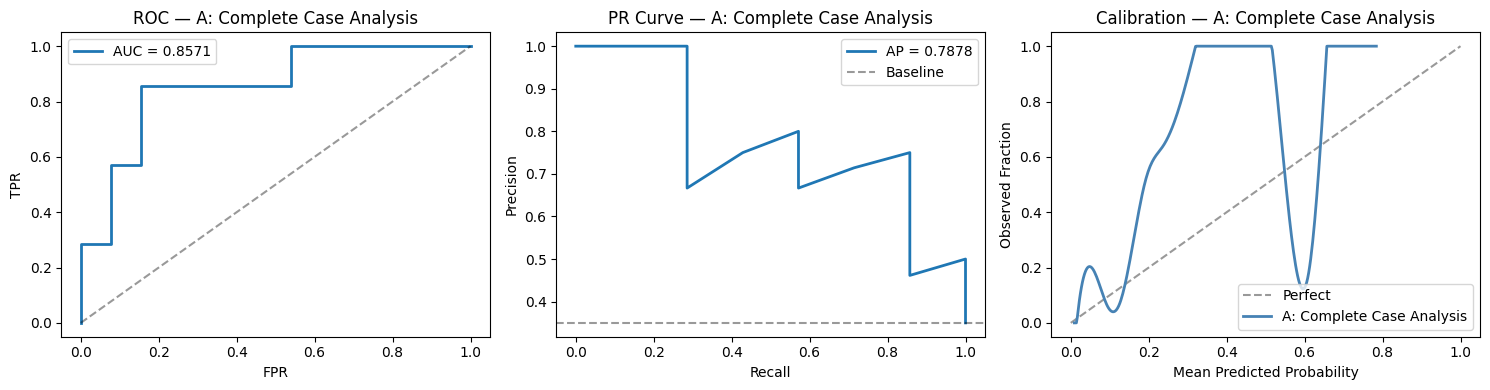

In [102]:
NAME = 'A: Complete Case Analysis'

# Keep only rows that are complete in the *training* set
train_cc = pd.concat([X_train_raw, y_train], axis=1).dropna()
X_cc = train_cc.drop(columns=[TARGET])
y_cc = train_cc[TARGET]

# Validation: also drop rows with any missing (strict complete-case)
val_cc = pd.concat([X_val_raw, y_val], axis=1).dropna()
X_val_cc = val_cc.drop(columns=[TARGET])
y_val_cc = val_cc[TARGET]

# Identify cat cols still present
cat_idx_cc = [X_cc.columns.get_loc(c) for c in CAT_COLS if c in X_cc.columns]

print(f'Training rows after dropping incomplete: {len(X_cc)} / {len(X_train_raw)} ({len(X_cc)/len(X_train_raw):.1%})')
print(f'Validation rows after dropping incomplete: {len(X_val_cc)} / {len(X_val_raw)}')

model_cc = CatBoostClassifier(**CB_PARAMS)
model_cc.fit(
    Pool(X_cc, y_cc, cat_features=cat_idx_cc),
    eval_set=Pool(X_val_cc, y_val_cc, cat_features=cat_idx_cc),
)

metrics_cc = evaluate_model(model_cc, X_val_cc, y_val_cc, cat_features=cat_idx_cc)
record(NAME, metrics_cc)
plot_experiment(NAME, metrics_cc['probs'], y_val_cc)

---
## 5. Experiment B — CatBoost Native Missing Value Handling

B: CatBoost Native (NaN as input)              AUROC=0.8921  AUPRC=0.5428  Brier=0.1183  Sens=0.7751  Spec=0.8385  PPV=0.3119  NPV=0.9753


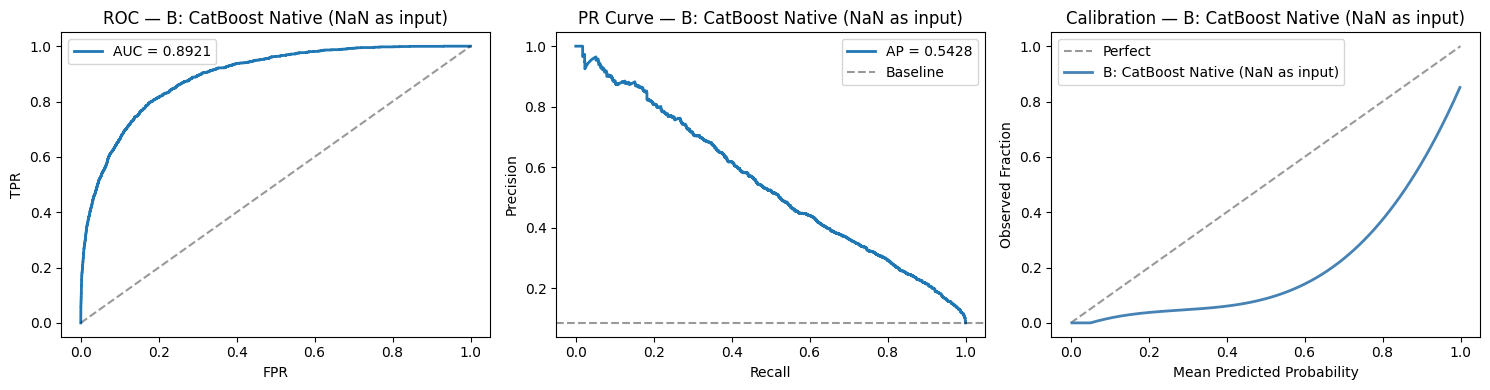

In [103]:
NAME = 'B: CatBoost Native (NaN as input)'

# CatBoost handles NaN natively for numerical columns.
# For categorical columns it needs strings — fill NaN with 'Unknown'.
def prep_cats(X):
    X = X.copy()
    for c in CAT_COLS:
        if c in X.columns:
            X[c] = X[c].fillna('Unknown').astype(str)
    return X

X_tr_b = prep_cats(X_train_raw)
X_vl_b = prep_cats(X_val_raw)

cat_idx_b = [X_tr_b.columns.get_loc(c) for c in CAT_COLS if c in X_tr_b.columns]

model_b = CatBoostClassifier(**CB_PARAMS)
model_b.fit(
    Pool(X_tr_b, y_train, cat_features=cat_idx_b),
    eval_set=Pool(X_vl_b, y_val, cat_features=cat_idx_b),
)

metrics_b = evaluate_model(model_b, X_vl_b, y_val, cat_features=cat_idx_b)
record(NAME, metrics_b)
plot_experiment(NAME, metrics_b['probs'], y_val)

---
## 6. Experiment C — Impute with "Missing" Category

C: Impute Missing Category                     AUROC=0.8921  AUPRC=0.5428  Brier=0.1183  Sens=0.7751  Spec=0.8385  PPV=0.3119  NPV=0.9753


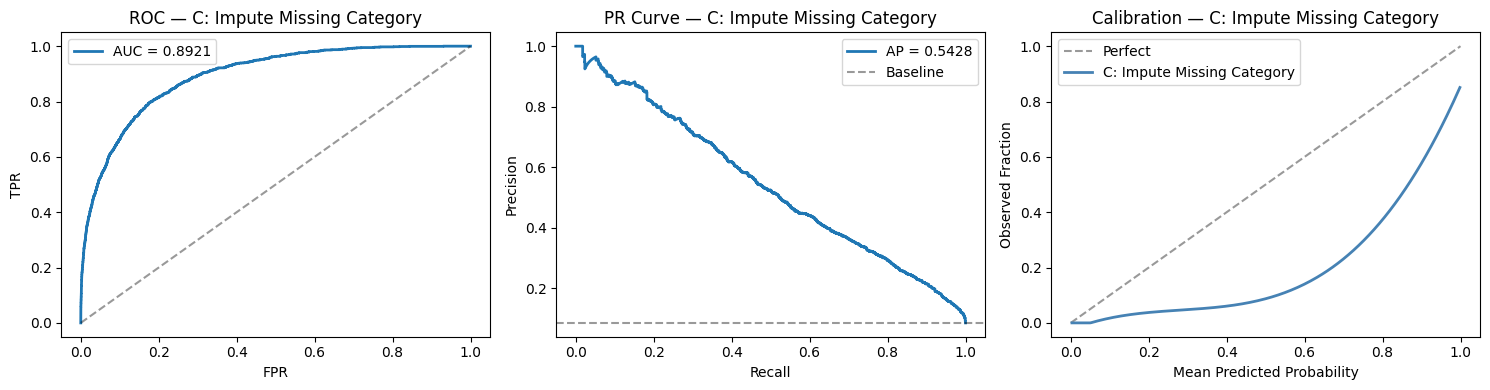

In [104]:
NAME = 'C: Impute Missing Category'

def impute_missing_category(X):
    X = X.copy()
    for c in X.columns:
        if c in CAT_COLS:
            X[c] = X[c].fillna('__MISSING__').astype(str)
        elif c in BIN_COLS:
            X[c] = X[c].fillna(-1)
        # Numeric: leave as NaN — CatBoost handles it natively
    return X

X_tr_c = impute_missing_category(X_train_raw)
X_vl_c = impute_missing_category(X_val_raw)

cat_idx_c = [X_tr_c.columns.get_loc(c) for c in CAT_COLS if c in X_tr_c.columns]

model_c = CatBoostClassifier(**CB_PARAMS)
model_c.fit(
    Pool(X_tr_c, y_train, cat_features=cat_idx_c),
    eval_set=Pool(X_vl_c, y_val, cat_features=cat_idx_c),
)

metrics_c = evaluate_model(model_c, X_vl_c, y_val, cat_features=cat_idx_c)
record(NAME, metrics_c)
plot_experiment(NAME, metrics_c['probs'], y_val)

---
## 7. Various Imputation Alternatives

Helper: encode categoricals as strings before imputation, then encode numerically.

In [105]:
def encode_cats(X):
    """Fill cat NaN with 'Unknown', keep as string (CatBoost will handle encoding)."""
    X = X.copy()
    for c in CAT_COLS:
        if c in X.columns:
            X[c] = X[c].fillna('Unknown').astype(str)
    return X

def get_cat_idx(X):
    return [X.columns.get_loc(c) for c in CAT_COLS if c in X.columns]

def train_eval(name, X_tr, X_vl, y_tr=y_train, y_vl=y_val):
    cat_idx = get_cat_idx(X_tr)
    m = CatBoostClassifier(**CB_PARAMS)
    m.fit(
        Pool(X_tr, y_tr, cat_features=cat_idx),
        eval_set=Pool(X_vl, y_vl, cat_features=cat_idx),
    )
    metrics = evaluate_model(m, X_vl, y_vl, cat_features=cat_idx)
    record(name, metrics)
    plot_experiment(name, metrics['probs'], y_vl)

print('Imputation helpers ready.')

Imputation helpers ready.


### D — Median Imputation (baseline numeric imputer)

D: Median Imputation                           AUROC=0.8916  AUPRC=0.5494  Brier=0.1184  Sens=0.7764  Spec=0.8422  PPV=0.3172  NPV=0.9755


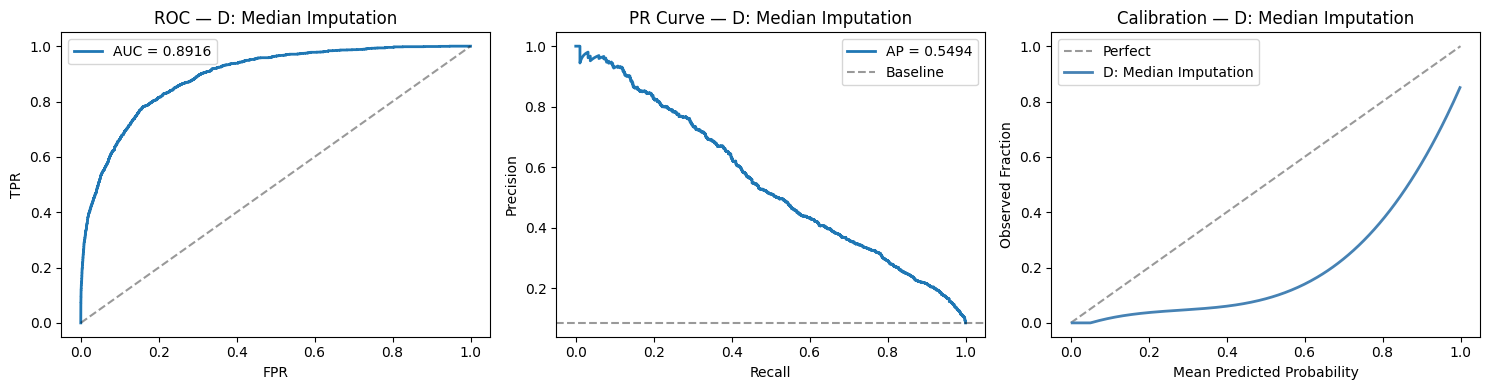

In [106]:
NAME = 'D: Median Imputation'

num_cols = [c for c in X_train_raw.columns if c not in CAT_COLS]

imp_d = SimpleImputer(strategy='median')

X_tr_d = encode_cats(X_train_raw.copy())
X_vl_d = encode_cats(X_val_raw.copy())

X_tr_d[num_cols] = imp_d.fit_transform(X_tr_d[num_cols])
X_vl_d[num_cols] = imp_d.transform(X_vl_d[num_cols])

train_eval(NAME, X_tr_d, X_vl_d)

### E — Median + Drop Columns > 80% Missing

Dropping 34 columns with >80% missing: ['h1_bilirubin_min', 'h1_bilirubin_max', 'h1_lactate_max', 'h1_lactate_min', 'h1_albumin_max', 'h1_albumin_min', 'h1_pao2fio2ratio_max', 'h1_pao2fio2ratio_min', 'h1_arterial_ph_max', 'h1_arterial_ph_min', 'h1_hco3_max', 'h1_hco3_min', 'h1_arterial_pco2_max', 'h1_arterial_pco2_min', 'h1_wbc_max', 'h1_wbc_min', 'h1_arterial_po2_min', 'h1_arterial_po2_max', 'h1_calcium_min', 'h1_calcium_max', 'h1_platelets_max', 'h1_platelets_min', 'h1_bun_max', 'h1_bun_min', 'h1_creatinine_max', 'h1_creatinine_min', 'h1_diasbp_invasive_min', 'h1_diasbp_invasive_max', 'h1_sysbp_invasive_max', 'h1_sysbp_invasive_min', 'h1_mbp_invasive_min', 'h1_mbp_invasive_max', 'h1_hematocrit_min', 'h1_hematocrit_max']
E: Median + Drop >80% Missing Cols             AUROC=0.8919  AUPRC=0.5512  Brier=0.1188  Sens=0.7720  Spec=0.8406  PPV=0.3138  NPV=0.9750


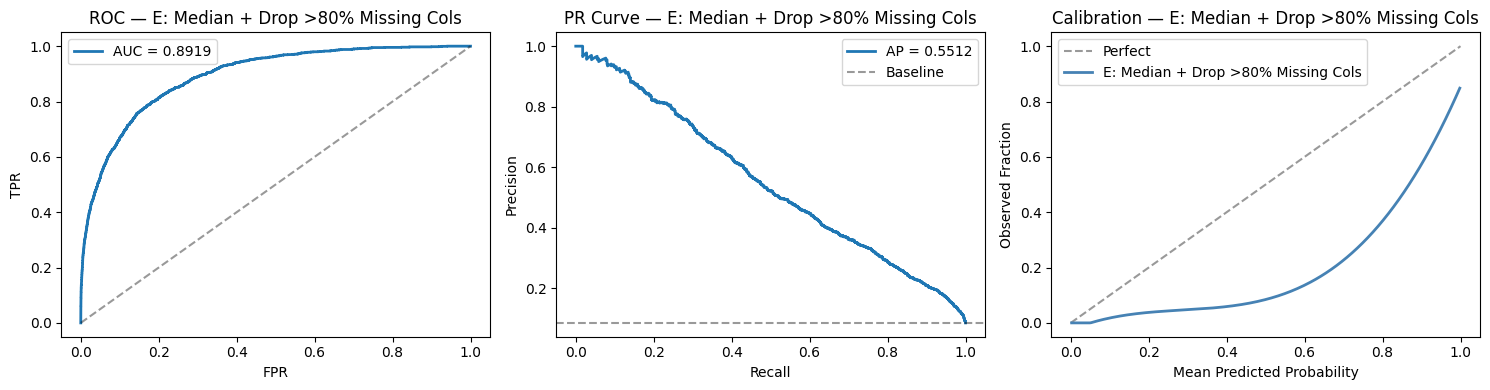

In [107]:
NAME = 'E: Median + Drop >80% Missing Cols'

SPARSE_CUTOFF = 0.80
sparse_cols = miss[miss > SPARSE_CUTOFF].index.tolist()
print(f'Dropping {len(sparse_cols)} columns with >{SPARSE_CUTOFF:.0%} missing: {sparse_cols}')

X_tr_e = encode_cats(X_train_raw.drop(columns=sparse_cols, errors='ignore').copy())
X_vl_e = encode_cats(X_val_raw.drop(columns=sparse_cols, errors='ignore').copy())

num_cols_e = [c for c in X_tr_e.columns if c not in CAT_COLS]
imp_e = SimpleImputer(strategy='median')
X_tr_e[num_cols_e] = imp_e.fit_transform(X_tr_e[num_cols_e])
X_vl_e[num_cols_e] = imp_e.transform(X_vl_e[num_cols_e])

train_eval(NAME, X_tr_e, X_vl_e)

### F — Flags + Median (Drop >80% Missing, Add `{col}_is_missing` Indicator for >5%)

  Dropped 34 cols, added 64 flag cols.
F: Flags + Median (drop >80%, flag >5%)        AUROC=0.8928  AUPRC=0.5499  Brier=0.1183  Sens=0.7650  Spec=0.8390  PPV=0.3097  NPV=0.9742


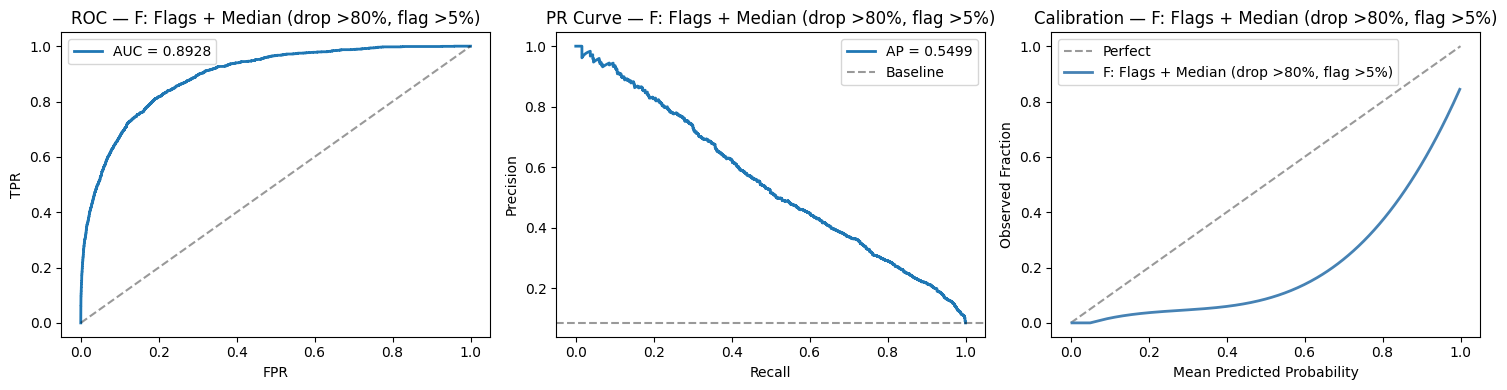

In [108]:
NAME = 'F: Flags + Median (drop >80%, flag >5%)'

FLAG_CUTOFF = 0.05

def add_flags_and_median(X_tr, X_vl, drop_cutoff=0.80, flag_cutoff=0.05):
    # Compute missing rates on training only
    tr_miss = X_tr.isnull().mean()
    cols_to_drop = tr_miss[tr_miss > drop_cutoff].index.tolist()
    cols_to_flag = [c for c in X_tr.columns
                    if c not in CAT_COLS and tr_miss[c] > flag_cutoff and c not in cols_to_drop]

    X_tr = X_tr.drop(columns=cols_to_drop, errors='ignore').copy()
    X_vl = X_vl.drop(columns=cols_to_drop, errors='ignore').copy()

    for c in cols_to_flag:
        X_tr[f'{c}_is_missing'] = X_tr[c].isnull().astype(int)
        X_vl[f'{c}_is_missing'] = X_vl[c].isnull().astype(int)

    X_tr = encode_cats(X_tr)
    X_vl = encode_cats(X_vl)

    num_c = [c for c in X_tr.columns if c not in CAT_COLS]
    imp = SimpleImputer(strategy='median')
    X_tr[num_c] = imp.fit_transform(X_tr[num_c])
    X_vl[num_c] = imp.transform(X_vl[num_c])

    print(f'  Dropped {len(cols_to_drop)} cols, added {len(cols_to_flag)} flag cols.')
    return X_tr, X_vl


X_tr_f, X_vl_f = add_flags_and_median(X_train_raw, X_val_raw, drop_cutoff=0.80, flag_cutoff=0.05)
train_eval(NAME, X_tr_f, X_vl_f)

### H — Iterative Imputer (IterativeImputer, 5 iterations)

  Dropped 34 cols, added 64 flag cols.
H: IterativeImputer (5 iters)                  AUROC=0.8921  AUPRC=0.5496  Brier=0.1178  Sens=0.7738  Spec=0.8388  PPV=0.3119  NPV=0.9752


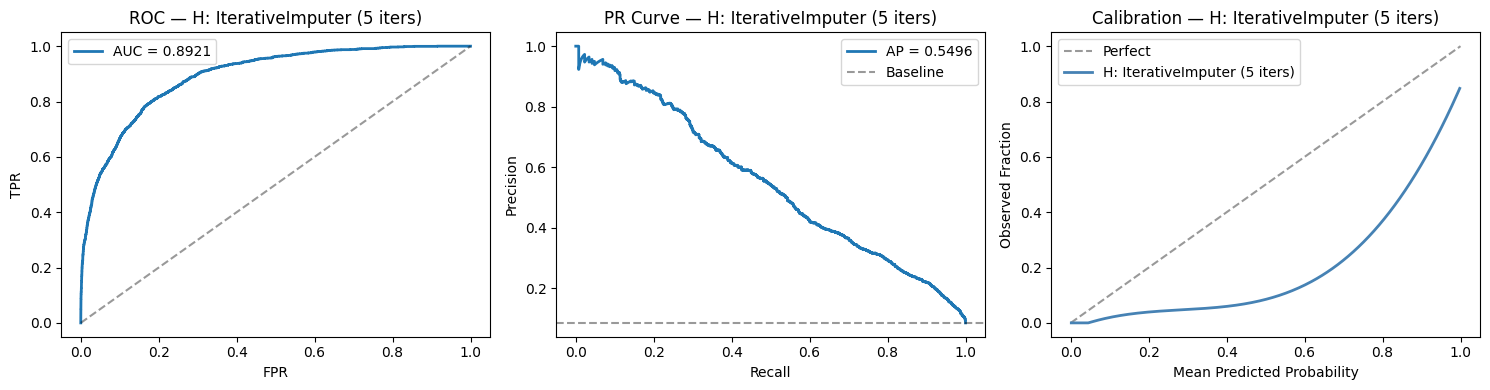

In [110]:
NAME = 'H: IterativeImputer (5 iters)'

def add_flags_and_iterative(X_tr, X_vl, drop_cutoff=0.80, flag_cutoff=0.05, max_iter=5):
    tr_miss = X_tr.isnull().mean()
    cols_to_drop = tr_miss[tr_miss > drop_cutoff].index.tolist()
    cols_to_flag = [c for c in X_tr.columns
                    if c not in CAT_COLS and tr_miss[c] > flag_cutoff and c not in cols_to_drop]

    X_tr = X_tr.drop(columns=cols_to_drop, errors='ignore').copy()
    X_vl = X_vl.drop(columns=cols_to_drop, errors='ignore').copy()

    for c in cols_to_flag:
        X_tr[f'{c}_is_missing'] = X_tr[c].isnull().astype(int)
        X_vl[f'{c}_is_missing'] = X_vl[c].isnull().astype(int)

    X_tr = encode_cats(X_tr)
    X_vl = encode_cats(X_vl)

    num_c = [c for c in X_tr.columns if c not in CAT_COLS]
    imp = IterativeImputer(estimator=BayesianRidge(), max_iter=max_iter, random_state=SEED)
    X_tr[num_c] = imp.fit_transform(X_tr[num_c])
    X_vl[num_c] = imp.transform(X_vl[num_c])

    print(f'  Dropped {len(cols_to_drop)} cols, added {len(cols_to_flag)} flag cols.')
    return X_tr, X_vl


X_tr_h, X_vl_h = add_flags_and_iterative(X_train_raw, X_val_raw, drop_cutoff=0.8, flag_cutoff=0.05)
train_eval(NAME, X_tr_h, X_vl_h)

### I — Multiple Imputation (m=5 datasets → averaged predictions)

  Imputation 1/5 done  AUC=0.8888
  Imputation 2/5 done  AUC=0.8880
  Imputation 3/5 done  AUC=0.8888
  Imputation 4/5 done  AUC=0.8894
  Imputation 5/5 done  AUC=0.8896
I: Multiple Imputation (MICE, m=5)             AUROC=0.8922  AUPRC=0.5471  Brier=0.1187  Sens=0.7720  Spec=0.8400  PPV=0.3130  NPV=0.9750


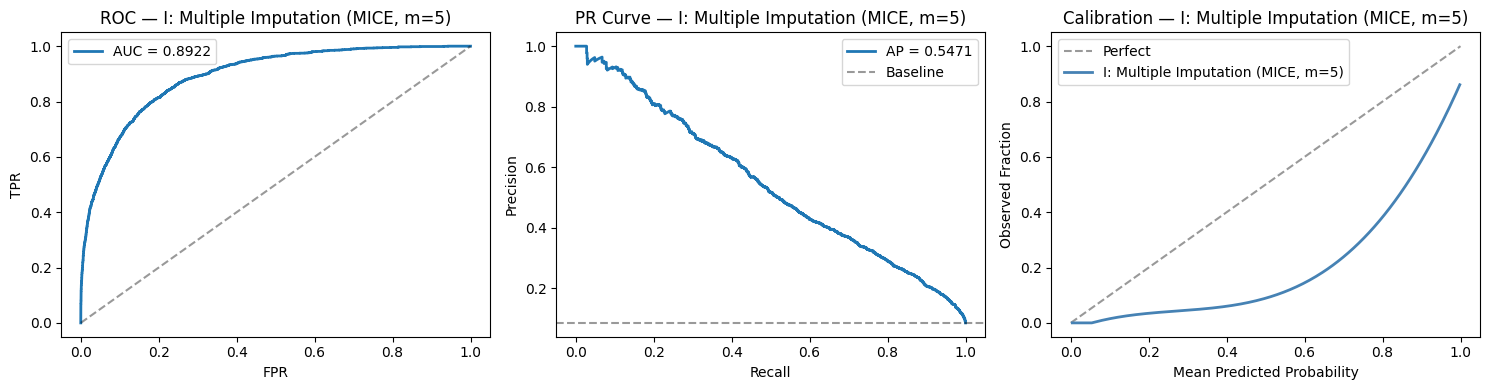

In [111]:
NAME = 'I: Multiple Imputation (m=5)'
M = 5  # number of imputed datasets

# Use 80% drop and flag at >5%
tr_miss = X_train_raw.isnull().mean()
cols_to_drop_mi = tr_miss[tr_miss > 0.80].index.tolist()
cols_to_flag_mi = [c for c in X_train_raw.columns
                   if c not in CAT_COLS and tr_miss[c] > 0.05 and c not in cols_to_drop_mi]

def prepare_mi_base(X, flag_cols, drop_cols):
    X = X.drop(columns=drop_cols, errors='ignore').copy()
    for c in flag_cols:
        if c in X.columns:
            X[f'{c}_is_missing'] = X[c].isnull().astype(int)
    X = encode_cats(X)
    return X

X_tr_base = prepare_mi_base(X_train_raw, cols_to_flag_mi, cols_to_drop_mi)
X_vl_base = prepare_mi_base(X_val_raw,   cols_to_flag_mi, cols_to_drop_mi)
# X_tr_base = prepare_mi_base(X_train_raw, flag_cols=[], drop_cols=[])
# X_vl_base = prepare_mi_base(X_val_raw,   flag_cols=[], drop_cols=[])
num_c_mi  = [c for c in X_tr_base.columns if c not in CAT_COLS]
cat_idx_mi = [X_tr_base.columns.get_loc(c) for c in CAT_COLS if c in X_tr_base.columns]

all_val_probs = []
for m_i in range(M):
    imp_m = IterativeImputer(estimator=BayesianRidge(), max_iter=5, sample_posterior=True, random_state=SEED + m_i)

    X_tr_m = X_tr_base.copy()
    X_vl_m = X_vl_base.copy()
    X_tr_m[num_c_mi] = imp_m.fit_transform(X_tr_m[num_c_mi])
    X_vl_m[num_c_mi] = imp_m.transform(X_vl_m[num_c_mi])

    model_m = CatBoostClassifier(**CB_PARAMS)
    model_m.fit(
        Pool(X_tr_m, y_train, cat_features=cat_idx_mi),
        eval_set=Pool(X_vl_m, y_val, cat_features=cat_idx_mi),
    )
    probs_m = model_m.predict_proba(Pool(X_vl_m, cat_features=cat_idx_mi))[:, 1]
    all_val_probs.append(probs_m)
    print(f'  Imputation {m_i+1}/{M} done  AUC={roc_auc_score(y_val, probs_m):.4f}')

# Rubin's rules: average predicted probabilities across imputations
probs_mi = np.mean(all_val_probs, axis=0)
preds_mi = (probs_mi >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_val, preds_mi).ravel()
metrics_mi = {
    'AUROC':       round(roc_auc_score(y_val, probs_mi), 4),
    'AUPRC':       round(average_precision_score(y_val, probs_mi), 4),
    'Brier':       round(brier_score_loss(y_val, probs_mi), 4),
    'Sensitivity': round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
    'Specificity': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
    'PPV':         round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0,
    'NPV':         round(tn / (tn + fn), 4) if (tn + fn) > 0 else 0,
    'probs':       probs_mi,
}
record(NAME, metrics_mi)
plot_experiment(NAME, metrics_mi['probs'], y_val)

---
## 9. Combined Comparison Plots

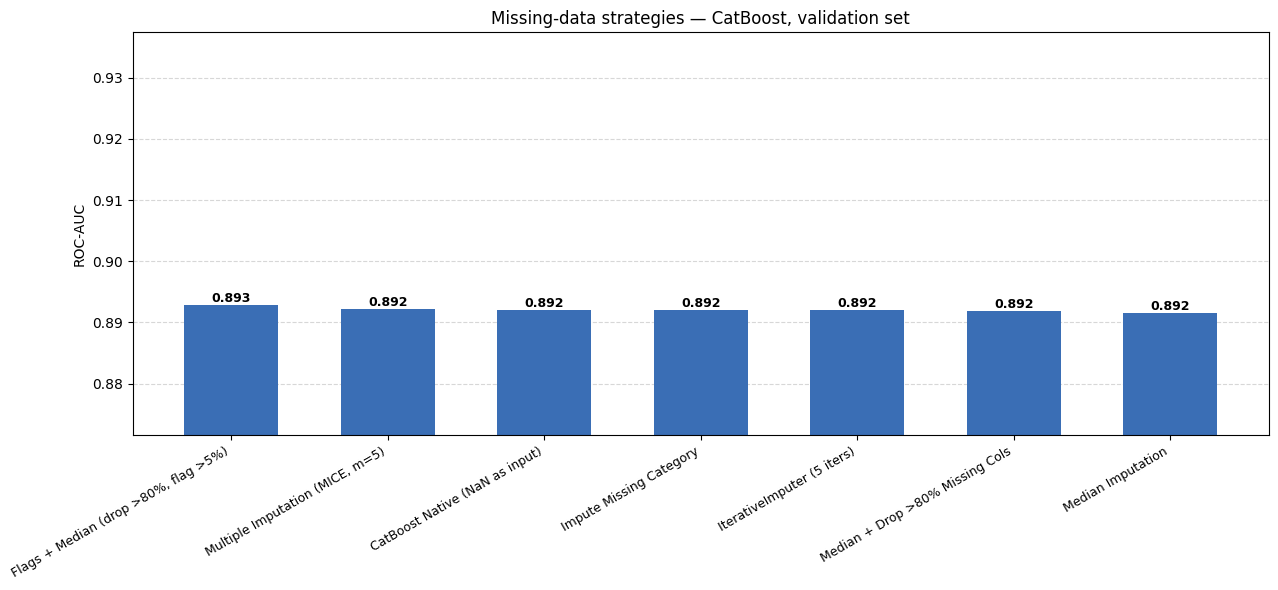

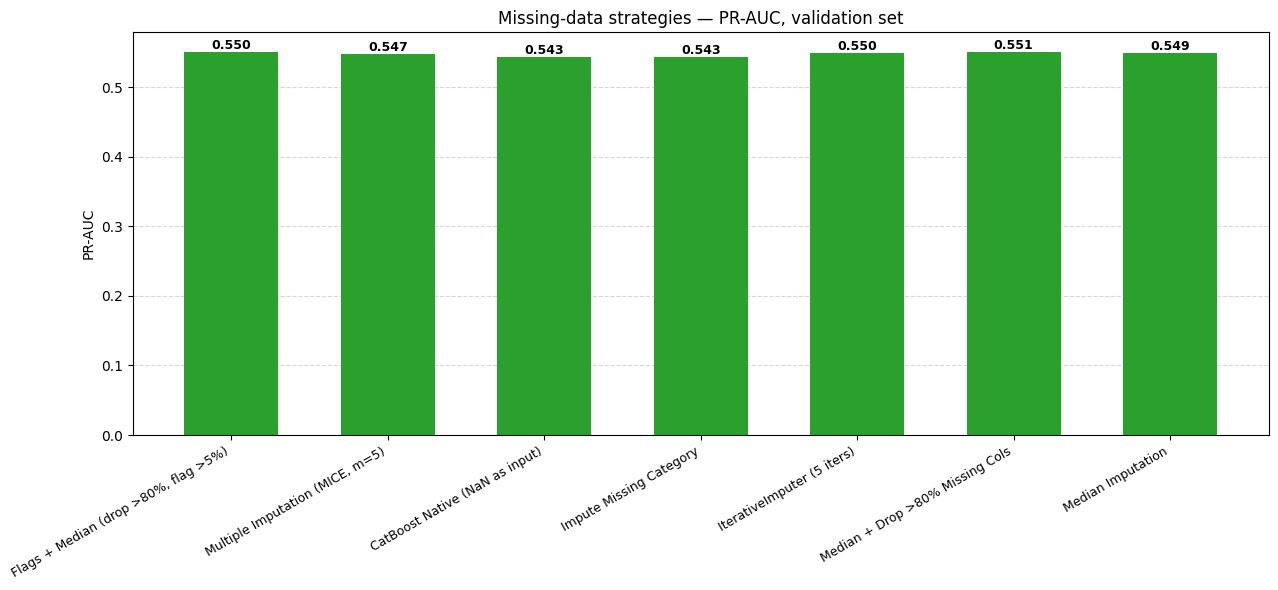

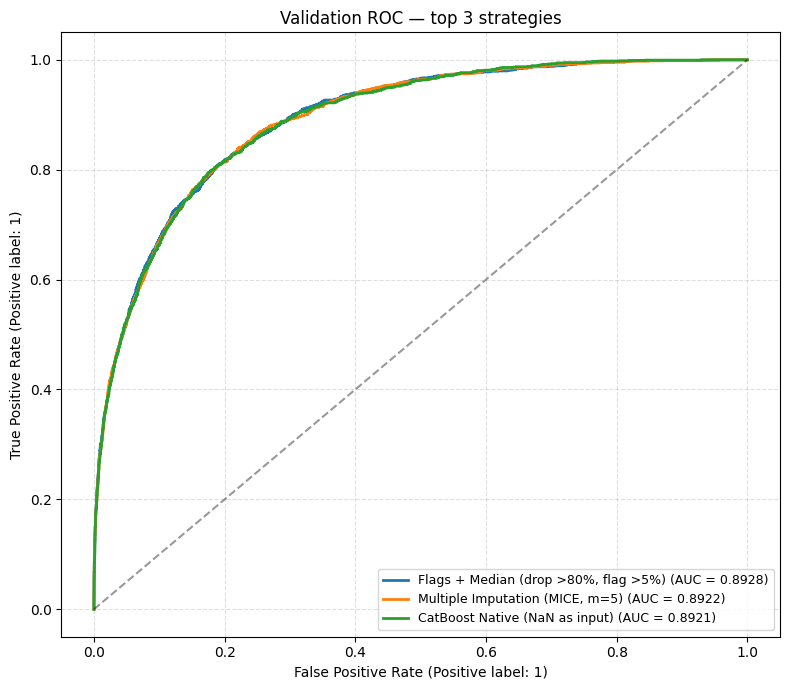

In [125]:
# ── Bar charts from validation results (no CV needed) ───────────────────────

# Build sorted lists from already-computed RESULTS
results_sorted = sorted(RESULTS, key=lambda r: r['AUROC'], reverse=True)

# Exclude A (different val subset) from the bar charts, same as combined plot
results_sorted_full = [r for r in results_sorted if not r['Strategy'].startswith('A:')]

names       = [r['Strategy'] for r in results_sorted_full]
auroc_vals  = [r['AUROC']    for r in results_sorted_full]
auprc_vals  = [r['AUPRC']    for r in results_sorted_full]
short_labels = [n.split(': ', 1)[1] for n in names]
x = np.arange(len(names))

# Feature counts from ALL_PROBS — use X_val shapes we already have
feat_counts = {
    'A: Complete Case Analysis': X_val_cc.shape[1],
    'B: CatBoost Native (NaN as input)':           X_vl_b.shape[1],
    'C: Impute Missing Category':                  X_vl_c.shape[1],
    'D: Median Imputation':                        X_vl_d.shape[1],
    'F: Flags + Median, drop >80%, flag >5% (Our Approach)':     X_vl_f.shape[1],
    'H: IterativeImputer (5 iters)':       X_vl_h.shape[1],
    'I: Multiple Imputation (MICE, m=5)':          X_vl_base.shape[1],
}
feat_vals = [feat_counts.get(n, 0) for n in names]

# ── Plot 1: ROC-AUC bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x, auroc_vals, color='#3a6eb5', width=0.6)
bars = ax.bar(x, auroc_vals, color='#3a6eb5', width=0.6)

for bar, val in zip(bars, auroc_vals):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('ROC-AUC')
ax.set_title('Missing-data strategies — CatBoost, validation set')
ax.set_ylim(bottom=min(auroc_vals) - 0.02)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# ── Plot 2: PR-AUC bar chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x, auprc_vals, color='#4caf6e', width=0.6)
bars = ax.bar(x, auprc_vals, color='#2ca02c', width=0.6)

for bar, val in zip(bars, auprc_vals):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('PR-AUC')
ax.set_title('Missing-data strategies — PR-AUC, validation set')
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# ── Plot 3: Validation ROC — top-3 strategies ────────────────────────────────
top3        = names[:3]
TOP3_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(8, 7))
y_np = np.array(y_val)

for name, color in zip(top3, TOP3_COLORS):
    probs = ALL_PROBS[name]
    fpr, tpr, _ = roc_curve(y_np, probs)
    auc = roc_auc_score(y_np, probs)
    label = name.split(': ', 1)[1]
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate (Positive label: 1)')
ax.set_ylabel('True Positive Rate (Positive label: 1)')
ax.set_title('Validation ROC — top 3 strategies')
ax.legend(loc='lower right', fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Curves Comparison

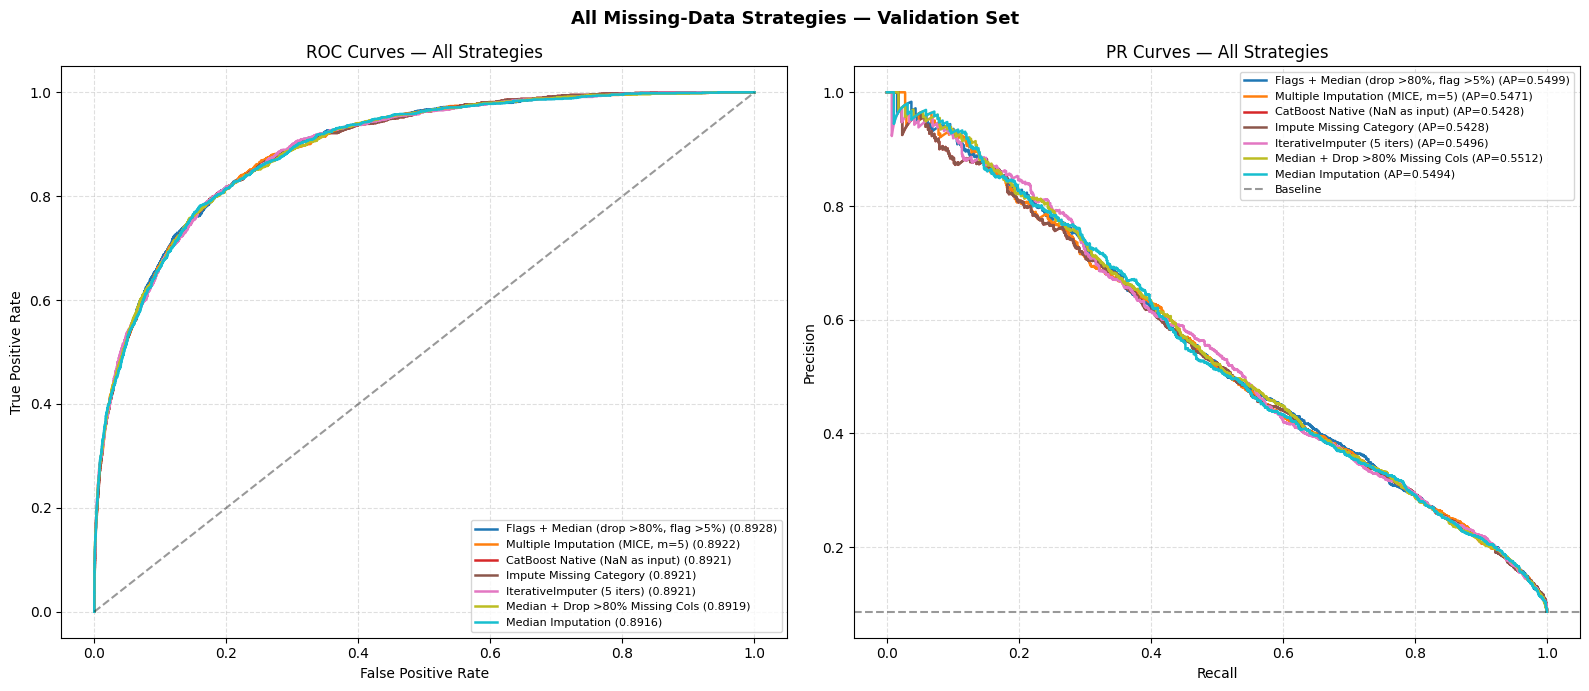

In [126]:
# ── All strategies overlaid: ROC + PR ────────────────────────────────────────
CMAP = plt.cm.get_cmap('tab10', len(names))
colors = [CMAP(i) for i in range(len(names))]

y_np     = np.array(y_val)
baseline = y_np.mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for name, color in zip(names, colors):
    probs = ALL_PROBS[name]
    label = name.split(': ', 1)[1]

    # ROC
    fpr, tpr, _ = roc_curve(y_np, probs)
    auc = roc_auc_score(y_np, probs)
    axes[0].plot(fpr, tpr, color=color, lw=1.8, label=f'{label} ({auc:.4f})')

    # PR
    prec, rec, _ = precision_recall_curve(y_np, probs)
    ap = average_precision_score(y_np, probs)
    axes[1].plot(rec, prec, color=color, lw=1.8, label=f'{label} (AP={ap:.4f})')

axes[0].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Strategies')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[0].xaxis.grid(True, linestyle='--', alpha=0.4)

axes[1].axhline(baseline, color='k', linestyle='--', alpha=0.4, label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves — All Strategies')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[1].xaxis.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('All Missing-Data Strategies — Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Performance Summary Table

In [128]:
results_df = pd.DataFrame(RESULTS).set_index('Strategy')
results_df = results_df.sort_values('AUROC', ascending=False)

# Add rank columns
results_df['AUROC Rank'] = results_df['AUROC'].rank(ascending=False).astype(int)
results_df['AUPRC Rank'] = results_df['AUPRC'].rank(ascending=False).astype(int)

results_df.to_csv("missing_data_strategy_results.csv")

print('\n' + '='*75)
print('PERFORMANCE SUMMARY — Missing Data Strategies')
print('='*75)
print(results_df.to_string())
print('='*75)

# Styled display
try:
    display(results_df.style
        .background_gradient(subset=['AUROC', 'AUPRC', 'Sensitivity', 'Specificity', 'PPV', 'NPV'], cmap='RdYlGn')
        .background_gradient(subset=['Brier'], cmap='RdYlGn_r')  # reversed: lower Brier = better
        .format({'AUROC': '{:.4f}', 'AUPRC': '{:.4f}', 'Brier': '{:.4f}',
                 'Sensitivity': '{:.4f}', 'Specificity': '{:.4f}',
                 'PPV': '{:.4f}', 'NPV': '{:.4f}'})
        .set_caption('Missing Data Strategies — Validation Performance')
    )
except Exception:
    pass


PERFORMANCE SUMMARY — Missing Data Strategies
                                          AUROC   AUPRC   Brier  Sensitivity  Specificity     PPV     NPV  AUROC Rank  AUPRC Rank
Strategy                                                                                                                         
F: Flags + Median (drop >80%, flag >5%)  0.8928  0.5499  0.1183       0.7650       0.8390  0.3097  0.9742           1           3
I: Multiple Imputation (MICE, m=5)       0.8922  0.5471  0.1187       0.7720       0.8400  0.3130  0.9750           2           6
B: CatBoost Native (NaN as input)        0.8921  0.5428  0.1183       0.7751       0.8385  0.3119  0.9753           4           7
C: Impute Missing Category               0.8921  0.5428  0.1183       0.7751       0.8385  0.3119  0.9753           4           7
H: IterativeImputer (5 iters)            0.8921  0.5496  0.1178       0.7738       0.8388  0.3119  0.9752           4           4
E: Median + Drop >80% Missing Cols       0.

,AUROC,AUPRC,Brier,Sensitivity,Specificity,PPV,NPV,AUROC Rank,AUPRC Rank
Strategy,,,,,,,,,
"F: Flags + Median (drop >80%, flag >5%)",0.8928,0.5499,0.1183,0.7650,0.8390,0.3097,0.9742,1,3
"I: Multiple Imputation (MICE, m=5)",0.8922,0.5471,0.1187,0.7720,0.8400,0.3130,0.9750,2,6
B: CatBoost Native (NaN as input),0.8921,0.5428,0.1183,0.7751,0.8385,0.3119,0.9753,4,7
C: Impute Missing Category,0.8921,0.5428,0.1183,0.7751,0.8385,0.3119,0.9753,4,7
H: IterativeImputer (5 iters),0.8921,0.5496,0.1178,0.7738,0.8388,0.3119,0.9752,4,4
E: Median + Drop >80% Missing Cols,0.8919,0.5512,0.1188,0.7720,0.8406,0.3138,0.9750,6,2
D: Median Imputation,0.8916,0.5494,0.1184,0.7764,0.8422,0.3172,0.9755,7,5
A: Complete Case Analysis,0.8571,0.7878,0.1825,0.4286,0.9231,0.7500,0.7500,8,1


---
## 11. Examples of Imputed Values (for Dr. Smith's Medical Review)

In [143]:
# Show specific imputed values so a clinician can assess medical plausibility
# We use the IterativeImputer result (Exp H) as the reference

SHOW_COLS = [
    c for c in [
        'bmi',
        'd1_glucose_max',
        'd1_temp_max',
        'd1_creatinine_max','d1_sodium_min'
    ]
    if c in X_train_raw.columns
]

# Choose rows with at least one missing value in the selected clinical columns
sample_mask = X_train_raw[SHOW_COLS].isnull().any(axis=1)
sample_idx = X_train_raw.loc[sample_mask].head(10).index

sample_orig = X_train_raw.loc[sample_idx, SHOW_COLS]
sample_imputed = X_tr_h.loc[sample_idx, [c for c in SHOW_COLS if c in X_tr_h.columns]]

# Build readable comparison table
comparison_rows = []

for idx in sample_idx:
    row = {"Patient row": idx}

    for col in SHOW_COLS:
        orig_val = sample_orig.loc[idx, col]

        if col in sample_imputed.columns:
            imp_val = sample_imputed.loc[idx, col]
        else:
            imp_val = np.nan

        if pd.isna(orig_val):
            row[col] = f"Missing → {imp_val:.2f}" if pd.notna(imp_val) else "Missing"
        else:
            row[col] = f"{orig_val:.2f}" if isinstance(orig_val, (int, float, np.number)) else str(orig_val)

    comparison_rows.append(row)

imputation_examples = pd.DataFrame(comparison_rows)

def highlight_imputed(val):
    if isinstance(val, str) and val.startswith("Missing"):
        return "background-color: #fff2cc; color: #b45f06; font-weight: bold;"
    return ""

styled_table = (
    imputation_examples
    .style
    .map(highlight_imputed)
    .set_caption("Examples of IterativeImputer values — Missing → Imputed")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "10px"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#d9d9d9"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid white"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid #eeeeee"),
                ("padding", "8px"),
            ],
        },
    ])
)

display(styled_table)

,Patient row,bmi,d1_glucose_max,d1_temp_max,d1_creatinine_max,d1_sodium_min
0,50977,32.99,153.00,Missing → 37.09,1.10,141.00
1,49648,18.43,145.00,Missing → 36.93,0.70,136.00
2,61962,26.02,368.00,36.90,Missing → 1.34,Missing → 136.22
3,50099,23.16,94.00,Missing → 36.84,1.00,142.00
4,68288,41.98,Missing → 161.83,37.30,Missing → 1.47,Missing → 136.07
5,48930,34.98,110.00,Missing → 37.18,0.90,141.00
6,14545,27.24,196.00,37.80,0.88,Missing → 138.70
7,10976,35.37,129.00,38.50,0.69,Missing → 137.69
8,2040,Missing → 28.64,121.00,38.20,1.51,139.00
9,43967,37.03,Missing → 140.44,38.70,Missing → 1.22,Missing → 138.18


# Show imputed values of our approach

In [142]:
# Show specific imputed values for Our Approach (F: Flags + Median, drop >80%, flag >5%)

SHOW_COLS = [
    c for c in [
        'bmi',
        'd1_glucose_max',
        'd1_temp_max',
        'd1_creatinine_max','d1_sodium_min'
    ]
    if c in X_train_raw.columns
]

sample_mask = X_train_raw[SHOW_COLS].isnull().any(axis=1)
sample_idx  = X_train_raw.loc[sample_mask].head(10).index

sample_orig    = X_train_raw.loc[sample_idx, SHOW_COLS]
sample_imputed = X_tr_f.loc[sample_idx, [c for c in SHOW_COLS if c in X_tr_f.columns]]  # ← X_tr_f

comparison_rows = []
for idx in sample_idx:
    row = {"Patient row": idx}
    for col in SHOW_COLS:
        orig_val = sample_orig.loc[idx, col]
        imp_val  = sample_imputed.loc[idx, col] if col in sample_imputed.columns else np.nan
        if pd.isna(orig_val):
            row[col] = f"Missing → {imp_val:.2f}" if pd.notna(imp_val) else "Missing (dropped col)"
        else:
            row[col] = f"{orig_val:.2f}" if isinstance(orig_val, (int, float, np.number)) else str(orig_val)
    comparison_rows.append(row)

imputation_examples = pd.DataFrame(comparison_rows)

def highlight_imputed(val):
    if isinstance(val, str) and val.startswith("Missing →"):
        return "background-color: #fff2cc; color: #b45f06; font-weight: bold;"
    if isinstance(val, str) and val.startswith("Missing (dropped"):
        return "background-color: #fce8e8; color: #cc0000; font-weight: bold;"
    return ""

styled_table = (
    imputation_examples
    .style
    .map(highlight_imputed)
    .set_caption("Examples of Median Imputation values — Our Approach (F: Flags + Median, drop >80%)")  # ← caption
    .set_table_styles([
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "18px"),
                                           ("font-weight", "bold"), ("text-align", "left"), ("padding", "10px")]},
        {"selector": "th",      "props": [("background-color", "#d9d9d9"), ("color", "black"),
                                           ("font-weight", "bold"), ("text-align", "center"), ("border", "1px solid white")]},
        {"selector": "td",      "props": [("text-align", "center"), ("border", "1px solid #eeeeee"), ("padding", "8px")]},
    ])
)

display(styled_table)

,Patient row,bmi,d1_glucose_max,d1_temp_max,d1_creatinine_max,d1_sodium_min
0,50977,32.99,153.00,Missing → 37.11,1.10,141.00
1,49648,18.43,145.00,Missing → 37.11,0.70,136.00
2,61962,26.02,368.00,36.90,Missing → 1.00,Missing → 138.00
3,50099,23.16,94.00,Missing → 37.11,1.00,142.00
4,68288,41.98,Missing → 150.00,37.30,Missing → 1.00,Missing → 138.00
5,48930,34.98,110.00,Missing → 37.11,0.90,141.00
6,14545,27.24,196.00,37.80,0.88,Missing → 138.00
7,10976,35.37,129.00,38.50,0.69,Missing → 138.00
8,2040,Missing → 27.64,121.00,38.20,1.51,139.00
9,43967,37.03,Missing → 150.00,38.70,Missing → 1.00,Missing → 138.00
